# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## MEDIAN-ASSIGNMENT GRAPH ANALYSIS (TOP 5% LTM)


This notebook adapts the original assignment-graph analysis by explicitly reading the p-median instance, assigning every facility to its nearest open median in each of the **top 5% best solutions** stored in long-term memory, and aggregating the resulting median-assignment links across that filtered subset.


### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import sys

from pathlib import Path

parent_path = Path().resolve().parent.parent

if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

In [2]:
import xopt
import pymedian

import numpy    as np
import networkx as nx
import seaborn  as sns
import matplotlib.pyplot as plt

from networkx.algorithms import community

This cell locates the "instances" folder in the project root and counts how many p-median instance files exist:

In [4]:
ROOT          = Path.cwd().resolve().parent.parent
INSTANCES_DIR = ROOT / "instances"

if not INSTANCES_DIR.exists():
    raise FileNotFoundError(f"Instances folder not found: {INSTANCES_DIR}")

print(f"Total number of p-median instances: {len(list(INSTANCES_DIR.glob('pmed[0-9]*.txt')))}")

Total number of p-median instances: 40


### APPLYING

We selected a few classic p-median instances and recorded the results obtained:

In [5]:
instance      = "pmed11.txt"
instance_path = str(INSTANCES_DIR / instance)

summary, details = pymedian.solve_pmedian(instance_path,
                                          restarts=8   ,
                                          max_iter=25  ,
                                          factor  =2   )

instance_obj = xopt.Instance(instance_path)

best_facilities = [
    idx - 1
    for idx in summary["tspmed_facilities"]
]

long_term_memory = details["long_term_memory"]

if not long_term_memory:
    raise ValueError("long_term_memory is empty")


print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()
print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

print()
print(f"Obs.: Distinct solutions recorded in long term memory is {summary['long_term_mem']}!")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [201, 98, 167, 24, 31]
  TSPMED    (7696.0): [201, 98, 167, 24, 31]

Obs.: Distinct solutions recorded in long term memory is 813!


In [7]:
TOP_FRACTION = 0.05


top_solution_count = max(
    1, int(np.ceil(len(long_term_memory) * TOP_FRACTION))
)

analysis_long_term_memory = sorted(
    long_term_memory,
    key=lambda sol: sol["cost"]
)[:top_solution_count]

analysis_costs = np.array(
    [
        sol["cost"]
        for sol in analysis_long_term_memory
    ],
    dtype=float
)

analysis_cost_cutoff = float(analysis_costs.max())


print(
    "Obs.: Analysis restricted to the top 5% best long-term memory solutions "
    f"by cost ({top_solution_count} solutions, max cost = {analysis_cost_cutoff:.1f})."
)

Obs.: Analysis restricted to the top 5% best long-term memory solutions by cost (41 solutions, max cost = 7739.0).


### MEDIAN-ASSIGNMENT NETWORK (TOP 5%)

To better understand how the elite near-optimal solutions distribute demand around the opened medians, we construct a **median-assignment adjacency matrix**. For each selected solution, every facility is assigned to its nearest open median according to the original instance distances. Then, for every assignment link between a facility and its serving median, we increment the corresponding matrix entry.

Thus, each entry $(i, j)$ represents how many times facilities *i* and *j* were linked by a nearest-median assignment relation across the filtered top-5% solution archive, with one of them acting as the open median for the other in that solution. This allows us to:

- Identify **stable assignment relations** that recur across elite near-optimal solutions
- Detect **persistent service areas** induced by frequently opened medians
- Reveal structural modules that combine median choice with customer allocation
- Provide a more interpretable view of the solution landscape beyond the set of selected medians alone

The resulting heatmap offers a visual representation of the collective assignment behavior of facilities across the filtered near-optimal solution set.


In [8]:
def decode_solution_indices(sol):
    facilities = np.asarray(
        sol["facilities"], dtype=int
    )

    return np.where(facilities == 1)[0]


def assign_facilities_to_medians(instance, medians):
    n = instance.get_n()

    medians_sorted = sorted  (int(v) for v in medians)
    nearest_median = np.empty(n, dtype=np.int64)
    nearest_dist   = np.empty(n, dtype=float   )

    for facility in range(n):
        best_median = medians_sorted[0]
        best_dist   = float(
            instance[facility, best_median]
        )

        for median in medians_sorted[1:]:
            dist = float(instance[facility, median])

            if dist < best_dist:
                best_dist   = dist
                best_median = median

        nearest_median[facility] = best_median
        nearest_dist  [facility] = best_dist

    return nearest_median, nearest_dist


def build_assignment_edges(instance, selected_medians):
    nearest_median, nearest_dist = assign_facilities_to_medians(
        instance, selected_medians
    )

    edges = set()

    for facility, median in enumerate(nearest_median):
        median = int(median)

        if facility == median:
            continue

        edges.add(
            tuple(
                sorted(
                    (facility, median)
                )
            )
        )

    return nearest_median, nearest_dist, edges

In [9]:
costs = analysis_costs.copy()

adjacency_matrix = np.zeros(
    (
        summary['n'],
        summary['n']
    ),
    dtype=int
)


selected_medians_by_solution = []
assigned_medians_by_solution = []
solution_edge_sets           = []

for sol in analysis_long_term_memory:
    selected_medians = decode_solution_indices(sol)

    nearest_median, _, edges = build_assignment_edges(
        instance_obj, selected_medians
    )

    selected_medians_by_solution.append(selected_medians)
    assigned_medians_by_solution.append(nearest_median  )
    solution_edge_sets          .append(edges           )

    for i, j in edges:
        adjacency_matrix[i, j] += 1
        adjacency_matrix[j, i] += 1

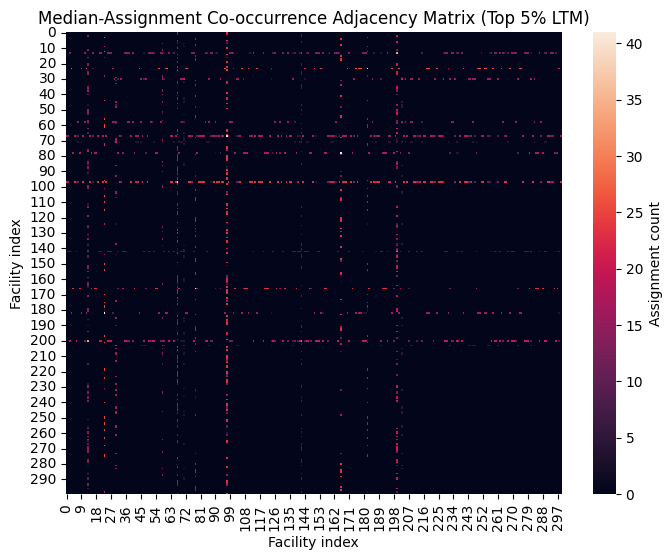

In [10]:
plt.figure (figsize=(8, 6))

sns.heatmap(
    adjacency_matrix, cbar_kws={'label': 'Assignment count'}
)

plt.title ("Median-Assignment Co-occurrence Adjacency Matrix (Top 5% LTM)")
plt.xlabel("Facility index")
plt.ylabel("Facility index")

plt.show()

The code below finds the **10 most frequent edges** in the adjacency matrix:

In [11]:
top_k = 10

upper_i, upper_j = np.triu_indices_from(adjacency_matrix, k=1)
upper_values     = adjacency_matrix[upper_i, upper_j]

top_pos = np.argpartition   (upper_values, -top_k )[-top_k:]
top_pos = top_pos[np.argsort(upper_values[top_pos])[::-1]]


print("Top 10 largest edge frequencies:")
print()

for pos in top_pos:
    i     = upper_i     [pos]
    j     = upper_j     [pos]
    value = upper_values[pos]

    print(f"({i}, {j}) -> {value}")

Top 10 largest edge frequencies:

(67, 97) -> 41
(23, 182) -> 41
(78, 166) -> 41
(13, 200) -> 33
(142, 200) -> 28
(23, 258) -> 25
(23, 250) -> 25
(23, 73) -> 25
(23, 263) -> 25
(23, 249) -> 25


### GREEDY MODULARITY COMMUNITY DETECTION

In this step, we convert the **median-assignment adjacency matrix** into a **weighted, undirected graph**:

- Each **node** represents a facility (indexed from `0` to `n-1`);
- An **edge** between facilities *(i, j)* exists if one of them was assigned to the other acting as an open median in at least one stored solution;
- The edge **weight** equals the number of repeated assignment relations, so stronger links correspond to more persistent median-service interactions.

We then apply **greedy modularity community detection** (Clauset-Newman-Moore) to partition the graph into **communities**. Each community is a group of facilities that tends to be linked by recurrent assignment relations more strongly **within the group** than with facilities outside the group.

For each detected community, we report:

- The community index;
- The number of facilities it contains;
- The subset of `best_facilities` that falls inside it;
- A short list of facility indices;
- The **average internal assignment frequency** (mean edge weight among connected facility pairs inside the community).

These communities can be interpreted as **recurring service modules** that characterize different regions of the filtered top-5% solution space.


In [12]:
G = nx.Graph()

G.add_nodes_from(range(summary['n']))

for i in range(summary['n']):
    for j in range(i + 1, summary['n']):
        if adjacency_matrix[i, j] > 0:
            G.add_edge(i, j, weight=adjacency_matrix[i, j])


communities = list(community.greedy_modularity_communities(G))

print(f"Greedy modularity found {len(communities)} communities!")

Greedy modularity found 4 communities!


In [13]:
best_set = set(best_facilities)

filtered = []

for idx, comm in enumerate(communities):
    if len(comm) <= 1:
        continue

    facilities_in_comm = sorted(list(comm))
    best_in_comm       = sorted(list(best_set.intersection(comm)))

    avg_cooccurrence = np.mean([
        adjacency_matrix[i, j]
        for i in facilities_in_comm
        for j in facilities_in_comm
        if i < j and adjacency_matrix[i, j] > 0
    ])

    filtered.append(
        (
            idx               ,
            facilities_in_comm,
            best_in_comm      ,
            avg_cooccurrence  ,
        )
    )


print(f"Communities shown (size > 1): {len(filtered)}")
print()

for idx, size, best_in_comm, cooccurrence in filtered:
    best_show = ", ".join(map(str, best_in_comm))

    print(f"Community {idx}:")
    print(f"{len(size)} facilities")
    print(f"  Avg assignment frequency of {cooccurrence:.2f}")
    print(f"  Best-solution medians in this community: {best_show}")

    print()


best_facilities_sorted = sorted(best_set)


print("*** Best solution medians ***")
print(f"  Count: {len(best_facilities_sorted)}")
print(f"  Medians: {', '.join(map(str, best_facilities_sorted))}")

Communities shown (size > 1): 4

Community 0:
105 facilities
  Avg assignment frequency of 18.56
  Best-solution medians in this community: 97

Community 1:
102 facilities
  Avg assignment frequency of 10.72
  Best-solution medians in this community: 30, 200

Community 2:
49 facilities
  Avg assignment frequency of 18.16
  Best-solution medians in this community: 166

Community 3:
44 facilities
  Avg assignment frequency of 18.72
  Best-solution medians in this community: 23

*** Best solution medians ***
  Count: 5
  Medians: 23, 30, 97, 166, 200
